In [1]:
import torch
import json
import numpy as np
import pandas as pd
from tqdm import tqdm
from protenix.utils.lmdb import LMDBDataset
from protenix.utils.plottool import init_plot_settings

import matplotlib.pyplot as plt

In [2]:
init_plot_settings()

In [3]:
with open("/data/rerank/protenix/chembl_bdb/protenis_statistics.json") as f:
    data = json.load(f)

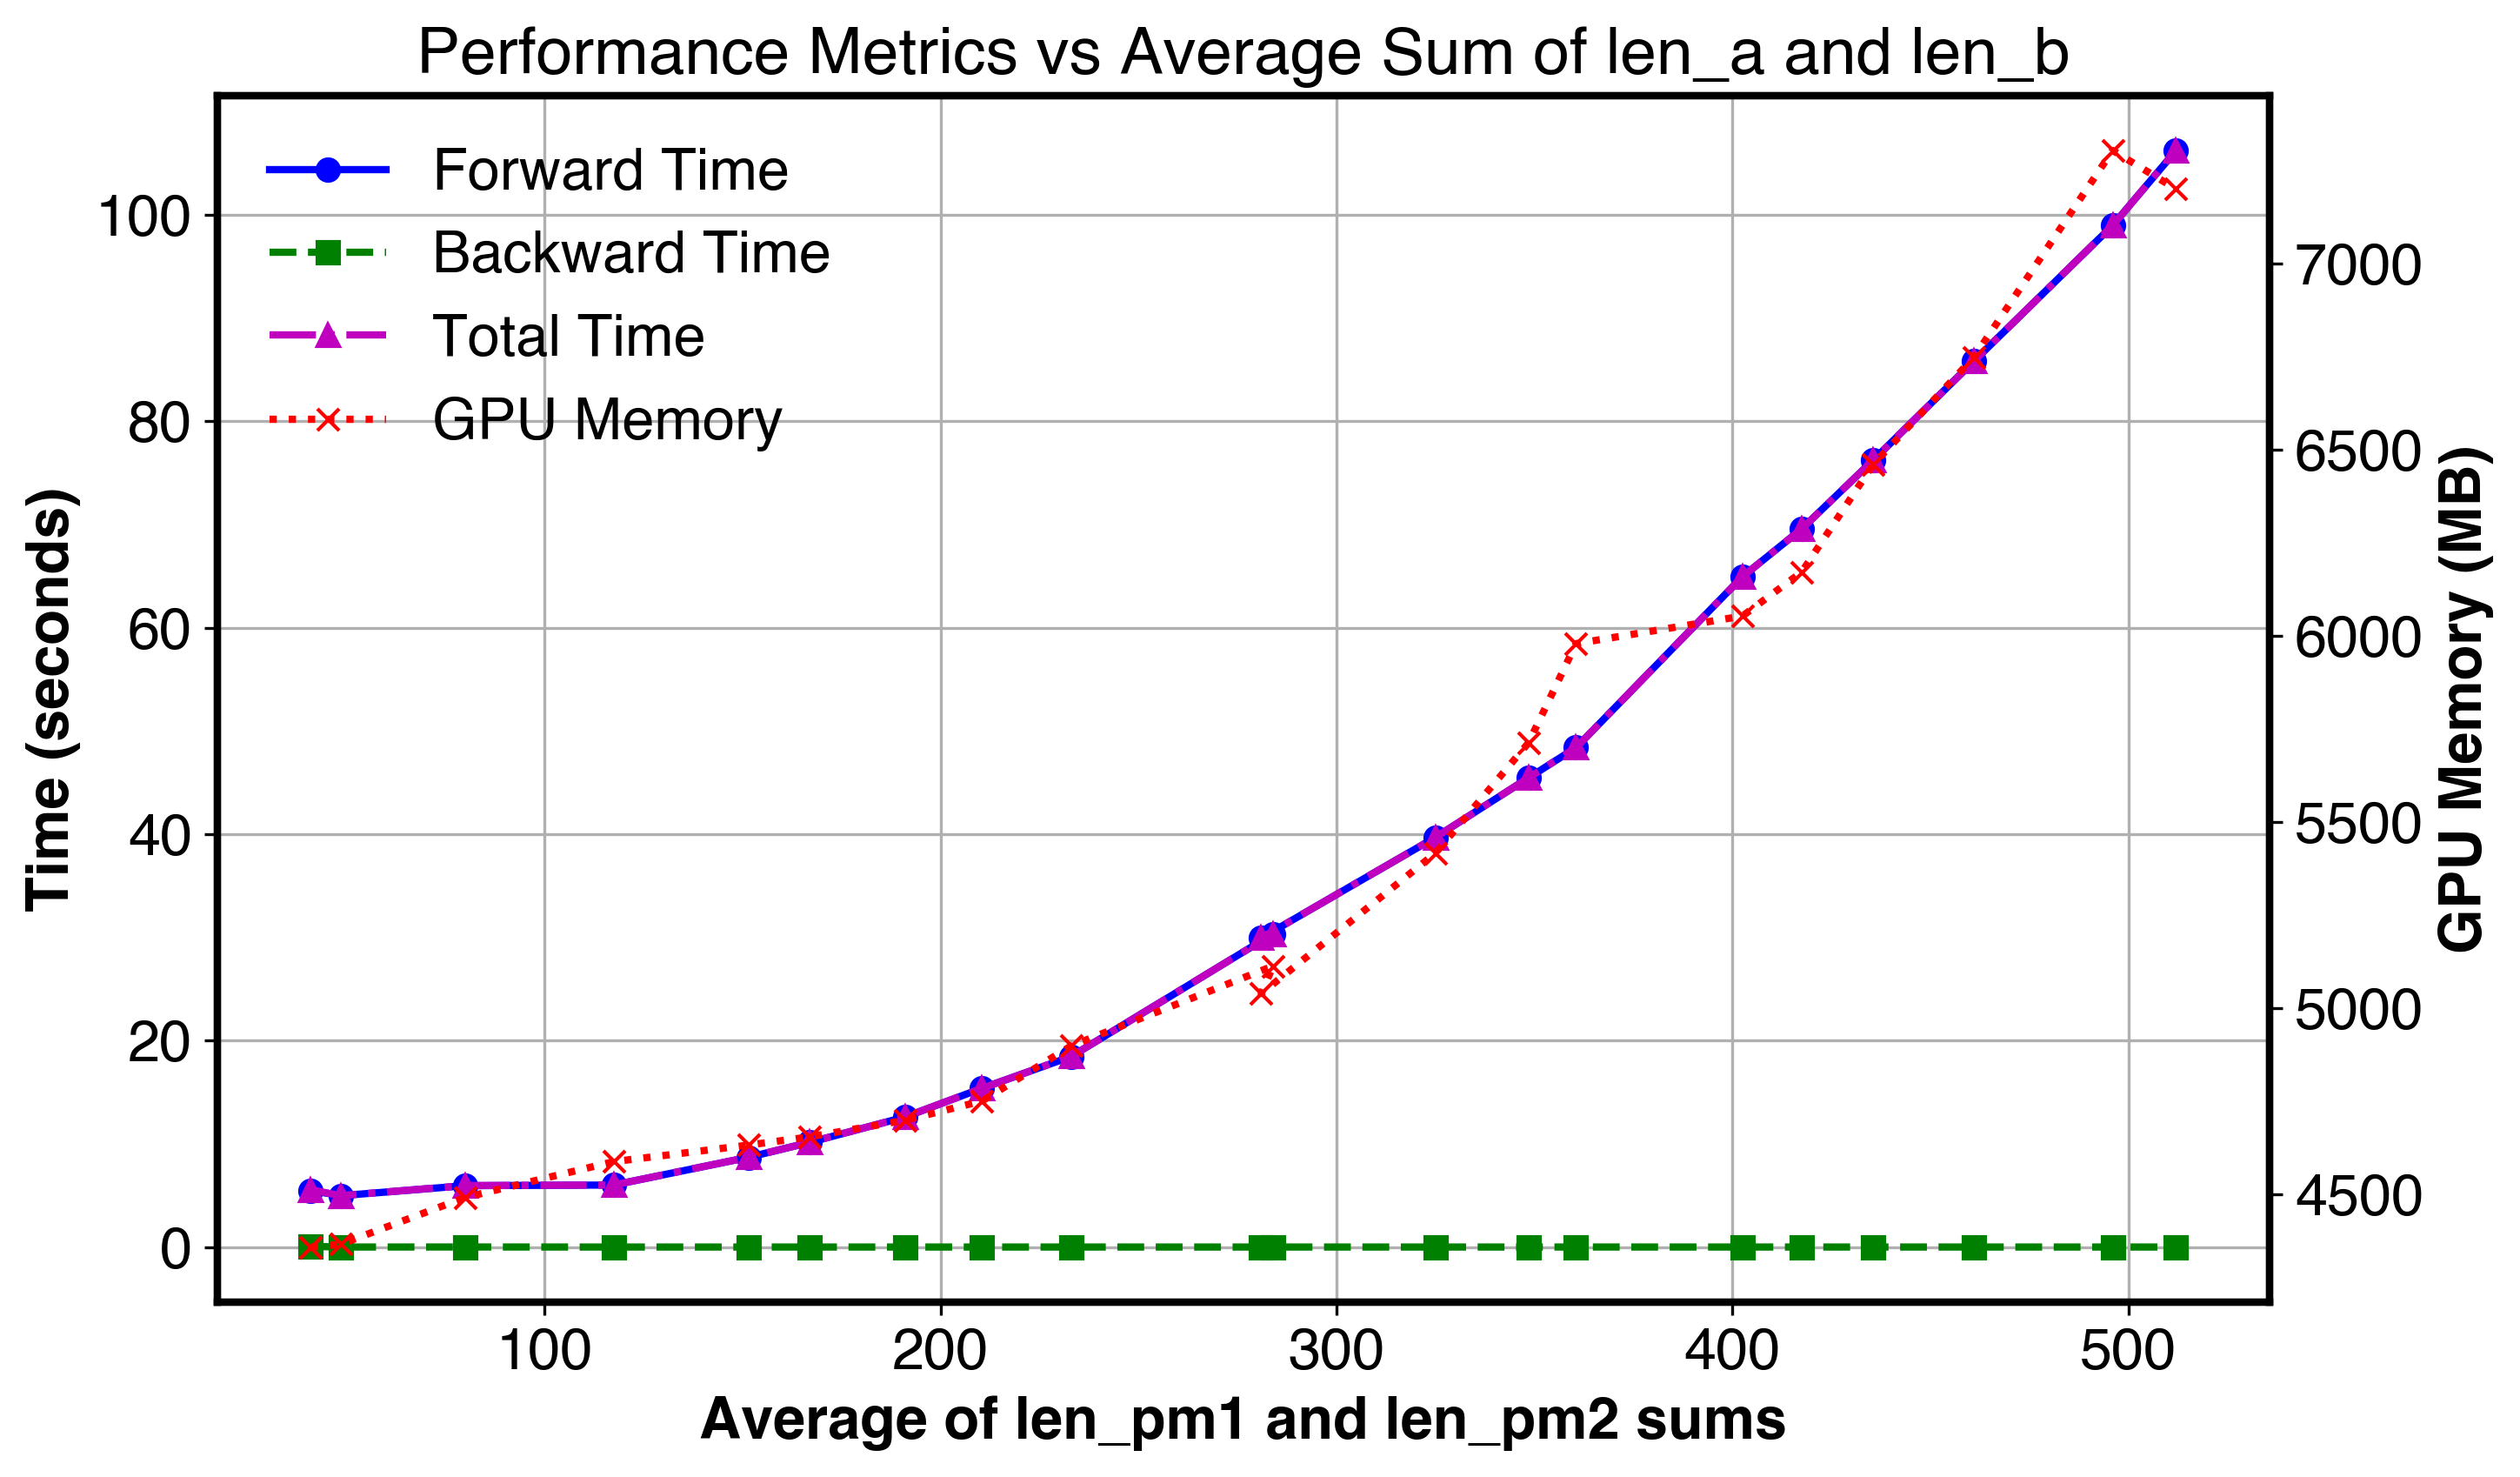

In [7]:
# 处理数据
keys = sorted(data.keys(), key=lambda x: int(x))
keys = keys[:20]
x_values = []
forward_times = []
backward_times = []
total_times = []
gpu_mems = []

for key in keys:
    entry = data[key]
    len_a_sum = sum(entry['len_a'])
    len_b_sum = sum(entry['len_b'])
    avg = (len_a_sum + len_b_sum) / 2
    x_values.append(avg)
    forward_times.append(entry['forward_use_time'])
    backward_times.append(entry['backward_use_time'])
    total_times.append(entry['total_use_time'])
    gpu_mems.append(entry['gpu_memory'] * 3.7)

# 创建图表
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# 绘制时间相关的三条线
ax1.plot(x_values, forward_times, 'b-', marker='o', label='Forward Time')
ax1.plot(x_values, backward_times, 'g--', marker='s', label='Backward Time')
ax1.plot(x_values, total_times, 'm-.', marker='^', label='Total Time')

# 绘制GPU内存线
ax2.plot(x_values, gpu_mems, 'r:', marker='x', label='GPU Memory')

# 设置标签和标题
ax1.set_xlabel('Average of len_pm1 and len_pm2 sums')
ax1.set_ylabel('Time (seconds)')
ax2.set_ylabel('GPU Memory (MB)')
plt.title('Performance Metrics vs Average Sum of len_a and len_b')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 显示网格
ax1.grid(True)

# 自动调整布局
plt.tight_layout()
plt.show()

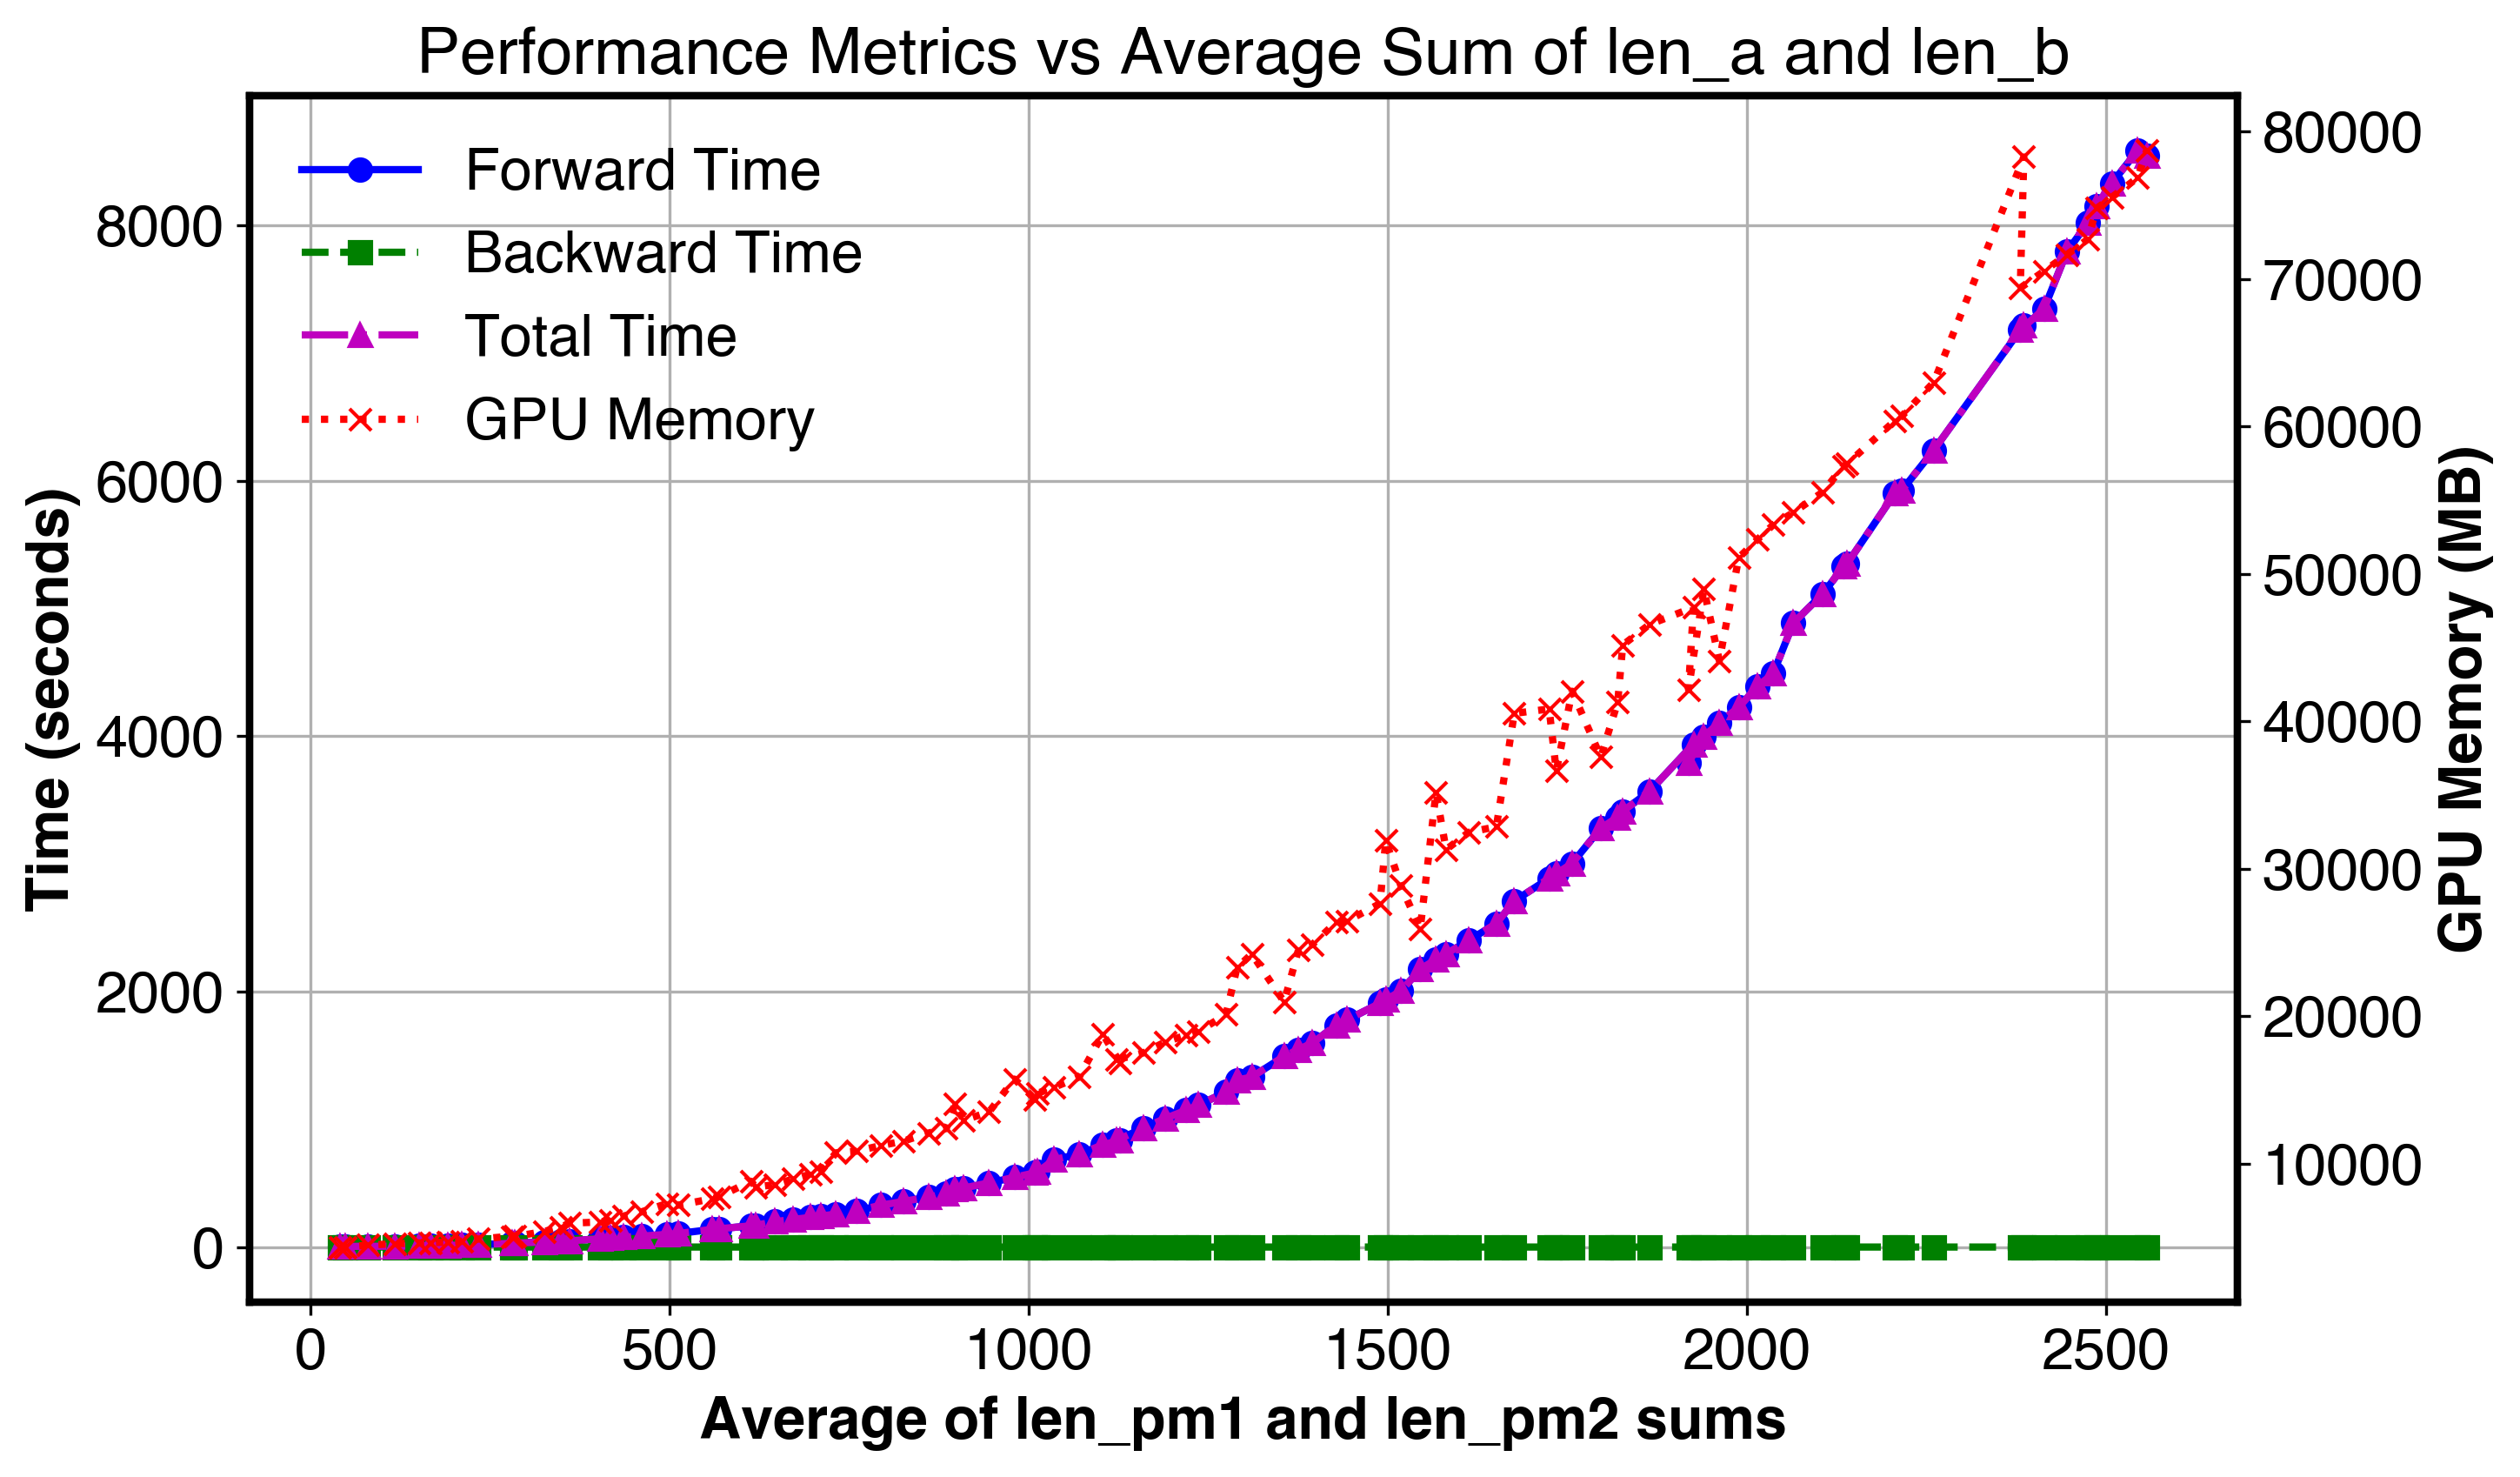

In [ ]:
# 处理数据
keys = sorted(data.keys(), key=lambda x: int(x))
x_values = []
forward_times = []
backward_times = []
total_times = []
gpu_mems = []

for key in keys:
    entry = data[key]
    len_a_sum = sum(entry['len_a'])
    len_b_sum = sum(entry['len_b'])
    avg = (len_a_sum + len_b_sum) / 2
    x_values.append(avg)
    forward_times.append(entry['forward_use_time'])
    backward_times.append(entry['backward_use_time'])
    total_times.append(entry['total_use_time'])
    gpu_mems.append(entry['gpu_memory'] * 3.7)

# 创建图表
fig, ax1 = plt.subplots(figsize=(10, 6))
ax2 = ax1.twinx()

# 绘制时间相关的三条线
ax1.plot(x_values, forward_times, 'b-', marker='o', label='Forward Time')
ax1.plot(x_values, backward_times, 'g--', marker='s', label='Backward Time')
ax1.plot(x_values, total_times, 'm-.', marker='^', label='Total Time')

# 绘制GPU内存线
ax2.plot(x_values, gpu_mems, 'r:', marker='x', label='GPU Memory')

# 设置标签和标题
ax1.set_xlabel('Average of len_pm1 and len_pm2 sums')
ax1.set_ylabel('Time (seconds)')
ax2.set_ylabel('GPU Memory (MB)')
plt.title('Performance Metrics vs Average Sum of len_a and len_b')

# 合并图例
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines1 + lines2, labels1 + labels2, loc='upper left')

# 显示网格
ax1.grid(True)

plt.yscale()

# 自动调整布局
plt.tight_layout()
plt.show()